In [1]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained('bert-base-uncased')
tokenizer

BertTokenizerFast(name_or_path='bert-base-uncased', vocab_size=30522, model_max_length=512, is_fast=True, padding_side='right', truncation_side='right', special_tokens={'unk_token': '[UNK]', 'sep_token': '[SEP]', 'pad_token': '[PAD]', 'cls_token': '[CLS]', 'mask_token': '[MASK]'}, clean_up_tokenization_spaces=False),  added_tokens_decoder={
	0: AddedToken("[PAD]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	100: AddedToken("[UNK]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	101: AddedToken("[CLS]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	102: AddedToken("[SEP]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	103: AddedToken("[MASK]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
}

In [2]:
# !wget https://github.com/npradaschnor/Pima-Indians-Diabetes-Dataset/raw/master/diabetes.csv
# #!unzip statlog+german+credit+data.zip

In [3]:
# !unzip census+income.zip

In [4]:
import pandas as pd

df = pd.read_csv('diabetes.csv')
print(len(df))
df

768


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [5]:
df.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')

In [6]:
import numpy as np
import torch

DROP_P = 0.2

def concatenate_text(x_full):
    x = {}
    for i, j in x_full.items():
        x[i] = j if np.random.random() > DROP_P else '[UNK]'
    
    text = "".join([f"I have information about a woman. ",
            f"She has been pregnant {x['Pregnancies']} times. ",
            f"Her plasma glucose concentration in an oral glucose tolerance test is {x['Glucose']}. ",
            f"Her diastolic blood pressure is {x['BloodPressure']} (mm Hg). ",
            f"Her triceps skin fold thickness is {x['SkinThickness']} (mm). ",
            f"Her 2-Hour serum insulin is {x['Insulin']} (mu U/ml). ",
            f"Her body mass index is {x['BMI']}. ",
            f"Her diabetes pedigree function {x['DiabetesPedigreeFunction']}. ",
            f"Her age is {x['Age']} years old."])

    
    return text

concatenate_text(df.iloc[0])

'I have information about a woman. She has been pregnant 6.0 times. Her plasma glucose concentration in an oral glucose tolerance test is 148.0. Her diastolic blood pressure is 72.0 (mm Hg). Her triceps skin fold thickness is 35.0 (mm). Her 2-Hour serum insulin is [UNK] (mu U/ml). Her body mass index is 33.6. Her diabetes pedigree function 0.627. Her age is 50.0 years old.'

In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(df.drop('Outcome', axis =1),
                                                    df['Outcome'],
                                                    test_size=.2,
                                                    random_state = 42)
# y_train = y_train.replace({1:1, 2:0})
# y_test = y_test.replace({1:1, 2:0})

X_train['text'] = X_train.apply(lambda x: concatenate_text(x), axis=1)
X_test['text'] = X_test.apply(lambda x: concatenate_text(x), axis=1)

X_train['label'] = y_train
X_test['label'] = y_test

In [8]:
X_train['text'].iloc[0]

'I have information about a woman. She has been pregnant 2.0 times. Her plasma glucose concentration in an oral glucose tolerance test is 84.0. Her diastolic blood pressure is 0.0 (mm Hg). Her triceps skin fold thickness is 0.0 (mm). Her 2-Hour serum insulin is 0.0 (mu U/ml). Her body mass index is 0.0. Her diabetes pedigree function 0.304. Her age is [UNK] years old.'

In [9]:
len(X_train)

614

In [10]:
import torch
from transformers import BertTokenizer, BertForSequenceClassification, Trainer, TrainingArguments
from datasets import Dataset
import numpy as np
import evaluate

# Define label mappings
# id2label = {0: "NOT-DONATE", 1: "DONATE"}
# label2id = {"NOT-DONATE": 0, "DONATE": 1}

# Convert to Hugging Face Dataset format
train_dataset = Dataset.from_pandas(X_train)
test_dataset = Dataset.from_pandas(X_test)

def tokenize_function(examples):
    # Adjust based on the structure of your dataset
    return tokenizer(examples['text'], padding='max_length', truncation=True, max_length=128)

tokenized_train_dataset = train_dataset.map(tokenize_function, batched=True)
tokenized_test_dataset = test_dataset.map(tokenize_function, batched=True)

# Format the datasets correctly with labels
tokenized_train_dataset = tokenized_train_dataset.map(lambda x: {'labels': x['label']})
tokenized_test_dataset = tokenized_test_dataset.map(lambda x: {'labels': x['label']})

Map:   0%|          | 0/614 [00:00<?, ? examples/s]

Map:   0%|          | 0/154 [00:00<?, ? examples/s]

Map:   0%|          | 0/614 [00:00<?, ? examples/s]

Map:   0%|          | 0/154 [00:00<?, ? examples/s]

In [11]:
tokenized_train_dataset[0].keys()

dict_keys(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'text', 'label', '__index_level_0__', 'input_ids', 'token_type_ids', 'attention_mask', 'labels'])

In [12]:
tokenized_train_dataset[0]['text']

'I have information about a woman. She has been pregnant 2.0 times. Her plasma glucose concentration in an oral glucose tolerance test is 84.0. Her diastolic blood pressure is 0.0 (mm Hg). Her triceps skin fold thickness is 0.0 (mm). Her 2-Hour serum insulin is 0.0 (mu U/ml). Her body mass index is 0.0. Her diabetes pedigree function 0.304. Her age is [UNK] years old.'

In [13]:
tokenized_train_dataset[0]['label']

0

In [14]:
import torch
if torch.backends.mps.is_available():
    mps_device = torch.device("mps")
    x = torch.ones(1, device=mps_device)
    print (x)
else:
    print ("MPS device not found.")
    

tensor([1.], device='mps:0')


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


  0%|          | 0/200 [00:00<?, ?it/s]

/Users/barebyxlol/Library/Python/3.9/lib/python/site-packages/torch/utils/data/dataloader.py:683: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)


{'loss': 28.2302, 'grad_norm': 10.740242004394531, 'learning_rate': 0.095, 'epoch': 1.0}


  0%|          | 0/3 [00:00<?, ?it/s]

...

test f1 0.0
test precision 0.0
test recall 0.0
test accuracy 0.6428571428571429
test roc_auc 0.5634527089072544



/Users/barebyxlol/Library/Python/3.9/lib/python/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/barebyxlol/Library/Python/3.9/lib/python/site-packages/torch/utils/data/dataloader.py:683: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)


  0%|          | 0/10 [00:00<?, ?it/s]

train f1 0.0
train precision 0.0
train recall 0.0
train accuracy 0.6530944625407166
train roc_auc 0.5622797466427827


/Users/barebyxlol/Library/Python/3.9/lib/python/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


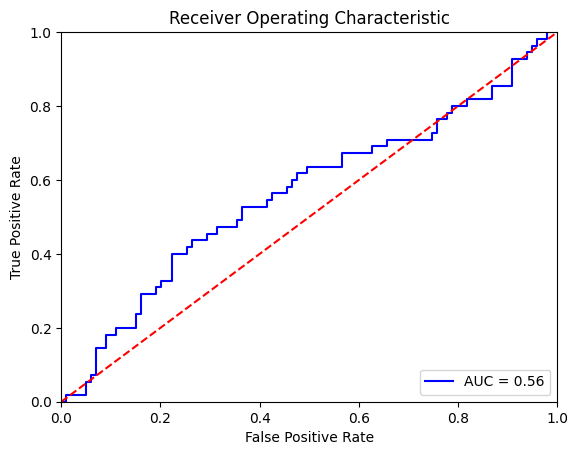

In [15]:
from transformers import BertForSequenceClassification
from transformers import DataCollatorWithPadding
from sklearn.metrics import f1_score, accuracy_score, precision_score, recall_score
from sklearn.metrics import roc_curve, auc
import sklearn.metrics as metrics
import matplotlib.pyplot as plt
import sklearn.metrics as metrics

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

model = BertForSequenceClassification.from_pretrained('bert-base-uncased', num_labels=2).to('mps')

model.dropout.p = 0

for param in model.bert.parameters():
    param.requires_grad = False

training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=20,
    per_device_train_batch_size=64,
    per_device_eval_batch_size=64,
    warmup_steps=00,
    learning_rate = 0.1,
    weight_decay=0.001,
    logging_dir='./logs',
    logging_steps=10,
    eval_strategy="epoch",
    report_to='none'
)

# Evaluation metric
auc = evaluate.load("roc_auc")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = torch.softmax(torch.tensor(logits), dim=1).numpy()[:, 1]
    return auc.compute(prediction_scores=predictions, references=labels)

def find_best_threshold(y_true, y_pred):
    best_threshold = 0.0
    best_f1 = 0.0
    best_accuracy = 0.0
    
    thresholds = np.arange(0.0, 1.01, 0.01)
    for threshold in thresholds:
        y_pred_binary = (y_pred >= threshold).astype(int)
        
        current_f1 = f1_score(y_true, y_pred_binary)
        
        if current_f1 > best_f1:
            best_f1 = current_f1
            best_threshold = threshold
            best_accuracy = accuracy_score(y_true, y_pred_binary)
    
    return best_f1, best_threshold

# Define the trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train_dataset,
    eval_dataset=tokenized_test_dataset,
    compute_metrics=compute_metrics,
    data_collator=data_collator
)

# Train the model
trainer.train()

results = trainer.evaluate()
print(results)

pred = trainer.predict(tokenized_test_dataset)
f1, thr = find_best_threshold(y_test, pred[0][:, 1])
print("test f1", f1)
print("test precision", precision_score(y_test, (pred[0][:, 1] >= thr).astype(int)))
print("test recall", recall_score(y_test, (pred[0][:, 1] >= thr).astype(int)))
print("test accuracy", accuracy_score(y_test, (pred[0][:, 1] >= thr).astype(int)))
fpr, tpr, threshold = roc_curve(y_test, pred[0][:, 1])
roc_auc = metrics.auc(fpr, tpr)
print("test roc_auc", roc_auc)
print("")

pred_train = trainer.predict(tokenized_train_dataset)
print("train f1", f1_score(y_train, np.argmax(pred_train[0], 1)))
print("train precision", precision_score(y_train, np.argmax(pred_train[0], 1)))
print("train recall", recall_score(y_train, np.argmax(pred_train[0], 1)))
print("train accuracy", accuracy_score(y_train, np.argmax(pred_train[0], 1)))

fpr_train, tpr_train, threshold_train = roc_curve(y_train, pred_train[0][:, 1])
roc_auc_train = metrics.auc(fpr_train, tpr_train)
print("train roc_auc", roc_auc_train)


plt.title('Receiver Operating Characteristic')
plt.plot(fpr, tpr, 'b', label = 'AUC = %0.2f' % roc_auc)
plt.legend(loc = 'lower right')
plt.plot([0, 1], [0, 1],'r--')
plt.xlim([0, 1])
plt.ylim([0, 1])
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.show()

  0%|          | 0/200 [00:00<?, ?it/s]

/Users/barebyxlol/Library/Python/3.9/lib/python/site-packages/torch/utils/data/dataloader.py:683: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)


{'loss': 0.6674, 'grad_norm': 7.735204219818115, 'learning_rate': 2.0000000000000002e-07, 'epoch': 1.0}


  0%|          | 0/3 [00:00<?, ?it/s]

{'eval_loss': 0.6494109034538269, 'eval_roc_auc': 0.5704315886134067, 'eval_runtime': 1.2013, 'eval_samples_per_second': 128.19, 'eval_steps_per_second': 2.497, 'epoch': 1.0}


...

  0%|          | 0/3 [00:00<?, ?it/s]

test f1 0.45454545454545453
test precision 0.6060606060606061
test recall 0.36363636363636365
test accuracy 0.6883116883116883
test roc_auc 0.691643709825528



/Users/barebyxlol/Library/Python/3.9/lib/python/site-packages/torch/utils/data/dataloader.py:683: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)


  0%|          | 0/10 [00:00<?, ?it/s]

train f1 0.6073298429319371
train precision 0.6863905325443787
train recall 0.5446009389671361
train accuracy 0.755700325732899
train roc_auc 0.7964712631566623


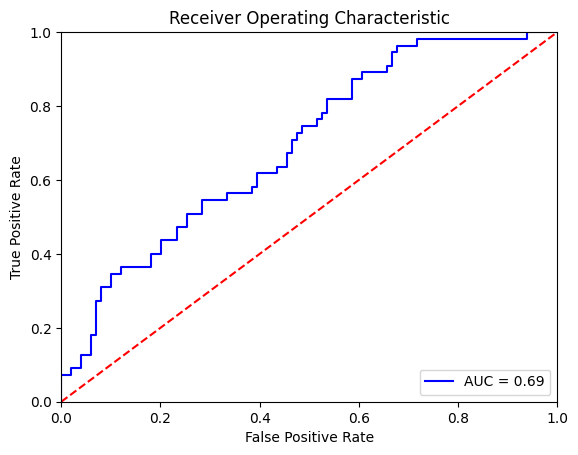

In [16]:
for param in model.bert.parameters():
    param.requires_grad = True

training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=20,
    per_device_train_batch_size=64,
    per_device_eval_batch_size=64,
    warmup_steps=500,
    learning_rate = 0.00001,
    weight_decay=0.001,
    logging_dir='./logs',
    logging_steps=10,
    eval_strategy="epoch",
    report_to='none'
)

# Evaluation metric
auc = evaluate.load("roc_auc")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = torch.softmax(torch.tensor(logits), dim=1).numpy()[:, 1]
    return auc.compute(prediction_scores=predictions, references=labels)

# Define the trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train_dataset,
    eval_dataset=tokenized_test_dataset,
    compute_metrics=compute_metrics,
    data_collator=data_collator
)

# Train the model
trainer.train()

results = trainer.evaluate()
print(results)

pred = trainer.predict(tokenized_test_dataset)
f1, thr = find_best_threshold(y_test, pred[0][:, 1])
print("test f1", f1)
print("test precision", precision_score(y_test, (pred[0][:, 1] >= thr).astype(int)))
print("test recall", recall_score(y_test, (pred[0][:, 1] >= thr).astype(int)))
print("test accuracy", accuracy_score(y_test, (pred[0][:, 1] >= thr).astype(int)))
fpr, tpr, threshold = roc_curve(y_test, pred[0][:, 1])
roc_auc = metrics.auc(fpr, tpr)
print("test roc_auc", roc_auc)
print("")

pred_train = trainer.predict(tokenized_train_dataset)
print("train f1", f1_score(y_train, np.argmax(pred_train[0], 1)))
print("train precision", precision_score(y_train, np.argmax(pred_train[0], 1)))
print("train recall", recall_score(y_train, np.argmax(pred_train[0], 1)))
print("train accuracy", accuracy_score(y_train, np.argmax(pred_train[0], 1)))

fpr_train, tpr_train, threshold_train = roc_curve(y_train, pred_train[0][:, 1])
roc_auc_train = metrics.auc(fpr_train, tpr_train)
print("train roc_auc", roc_auc_train)


plt.title('Receiver Operating Characteristic')
plt.plot(fpr, tpr, 'b', label = 'AUC = %0.2f' % roc_auc)
plt.legend(loc = 'lower right')
plt.plot([0, 1], [0, 1],'r--')
plt.xlim([0, 1])
plt.ylim([0, 1])
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.show()

In [17]:
from sklearn.utils import resample
from sklearn.metrics import roc_auc_score

scores = []
n_iter = 1000
multi = False
y_pred = (pred[0][:, 1] >= thr).astype(int)
for i in range(n_iter):
    y_true_boot, y_pred_boot, y_prob_boot = resample(y_test, y_pred, pred[0][:, 1], random_state=i+1)
    try:
        if multi:
            auc = roc_auc_score(y_true_boot, y_prob_boot, multi_class="ovr", average="macro")
            f1 = f1_score(y_true_boot, y_pred_boot, average="macro")
            pr = precision_score(y_true_boot, y_pred_boot, average="macro", zero_division=0)
            rc = recall_score (y_true_boot, y_pred_boot, average="macro", zero_division=0)
        else:
            auc = roc_auc_score(y_true_boot, y_prob_boot)
            f1  = f1_score(y_true_boot, y_pred_boot)
            pr  = precision_score(y_true_boot, y_pred_boot, zero_division=0)
            rc  = recall_score (y_true_boot, y_pred_boot, zero_division=0)
        scores.append((auc, f1, accuracy_score(y_true_boot, y_pred_boot), pr, rc))
    except ValueError:
        continue
scores = np.asarray(scores)
means, stds = scores.mean(0), scores.std(0, ddof=1)
names = ["ROC-AUC", "F1", "Accuracy", "Precision", "Recall"]
{n: f"{m:.4f}±{s:.4f}" for n, m, s in zip(names, means, stds)}

{'ROC-AUC': '0.6917±0.0420',
 'F1': '0.4522±0.0646',
 'Accuracy': '0.6889±0.0385',
 'Precision': '0.6078±0.0844',
 'Recall': '0.3635±0.0630'}

Map:   0%|          | 0/614 [00:00<?, ? examples/s]

Map:   0%|          | 0/154 [00:00<?, ? examples/s]

Map:   0%|          | 0/614 [00:00<?, ? examples/s]

Map:   0%|          | 0/154 [00:00<?, ? examples/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


...

test f1 0.0
test precision 0.0
test recall 0.0
test accuracy 0.6428571428571429
test roc_auc 0.5213957759412304



/Users/barebyxlol/Library/Python/3.9/lib/python/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/barebyxlol/Library/Python/3.9/lib/python/site-packages/torch/utils/data/dataloader.py:683: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)


  0%|          | 0/10 [00:00<?, ?it/s]

train f1 0.0
train precision 0.0
train recall 0.0
train accuracy 0.6530944625407166
train roc_auc 0.5768559821104515


/Users/barebyxlol/Library/Python/3.9/lib/python/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


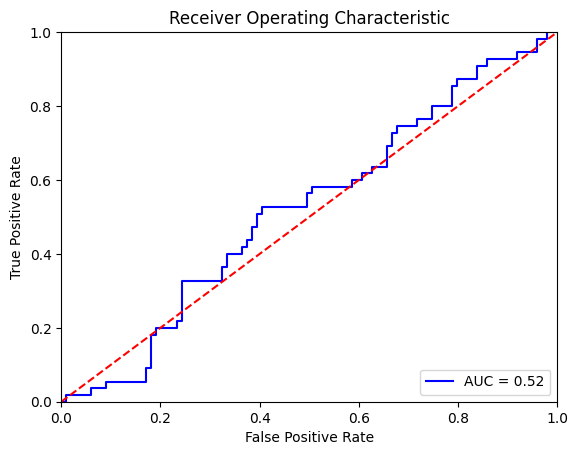

In [18]:
DROP_P = 0.5

X_train, X_test, y_train, y_test = train_test_split(df.drop('Outcome', axis =1),
                                                    df['Outcome'],
                                                    test_size=.2,
                                                    random_state = 42)
# y_train = y_train.replace({1:1, 2:0})
# y_test = y_test.replace({1:1, 2:0})

X_train['text'] = X_train.apply(lambda x: concatenate_text(x), axis=1)
X_test['text'] = X_test.apply(lambda x: concatenate_text(x), axis=1)

X_train['label'] = y_train
X_test['label'] = y_test

train_dataset = Dataset.from_pandas(X_train)
test_dataset = Dataset.from_pandas(X_test)

tokenized_train_dataset = train_dataset.map(tokenize_function, batched=True)
tokenized_test_dataset = test_dataset.map(tokenize_function, batched=True)

# Format the datasets correctly with labels
tokenized_train_dataset = tokenized_train_dataset.map(lambda x: {'labels': x['label']})
tokenized_test_dataset = tokenized_test_dataset.map(lambda x: {'labels': x['label']})

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

model = BertForSequenceClassification.from_pretrained('bert-base-uncased', num_labels=2).to('mps')

model.dropout.p = 0

for param in model.bert.parameters():
    param.requires_grad = False

training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=20,
    per_device_train_batch_size=64,
    per_device_eval_batch_size=64,
    warmup_steps=00,
    learning_rate = 0.1,
    weight_decay=0.001,
    logging_dir='./logs',
    logging_steps=10,
    eval_strategy="epoch",
    report_to='none'
)

# Evaluation metric
auc = evaluate.load("roc_auc")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = torch.softmax(torch.tensor(logits), dim=1).numpy()[:, 1]
    return auc.compute(prediction_scores=predictions, references=labels)

# Define the trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train_dataset,
    eval_dataset=tokenized_test_dataset,
    compute_metrics=compute_metrics,
    data_collator=data_collator
)

# Train the model
trainer.train()

results = trainer.evaluate()
print(results)

pred = trainer.predict(tokenized_test_dataset)
f1, thr = find_best_threshold(y_test, pred[0][:, 1])
print("test f1", f1)
print("test precision", precision_score(y_test, (pred[0][:, 1] >= thr).astype(int)))
print("test recall", recall_score(y_test, (pred[0][:, 1] >= thr).astype(int)))
print("test accuracy", accuracy_score(y_test, (pred[0][:, 1] >= thr).astype(int)))
fpr, tpr, threshold = roc_curve(y_test, pred[0][:, 1])
roc_auc = metrics.auc(fpr, tpr)
print("test roc_auc", roc_auc)
print("")

pred_train = trainer.predict(tokenized_train_dataset)
print("train f1", f1_score(y_train, np.argmax(pred_train[0], 1)))
print("train precision", precision_score(y_train, np.argmax(pred_train[0], 1)))
print("train recall", recall_score(y_train, np.argmax(pred_train[0], 1)))
print("train accuracy", accuracy_score(y_train, np.argmax(pred_train[0], 1)))

fpr_train, tpr_train, threshold_train = roc_curve(y_train, pred_train[0][:, 1])
roc_auc_train = metrics.auc(fpr_train, tpr_train)
print("train roc_auc", roc_auc_train)


plt.title('Receiver Operating Characteristic')
plt.plot(fpr, tpr, 'b', label = 'AUC = %0.2f' % roc_auc)
plt.legend(loc = 'lower right')
plt.plot([0, 1], [0, 1],'r--')
plt.xlim([0, 1])
plt.ylim([0, 1])
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.show()

  0%|          | 0/200 [00:00<?, ?it/s]

/Users/barebyxlol/Library/Python/3.9/lib/python/site-packages/torch/utils/data/dataloader.py:683: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)


{'loss': 0.6354, 'grad_norm': 8.22840404510498, 'learning_rate': 2.0000000000000002e-07, 'epoch': 1.0}


  0%|          | 0/3 [00:00<?, ?it/s]

{'eval_loss': 0.6660237908363342, 'eval_roc_auc': 0.5188246097337006, 'eval_runtime': 1.2212, 'eval_samples_per_second': 126.103, 'eval_steps_per_second': 2.457, 'epoch': 1.0}


...

  0%|          | 0/3 [00:00<?, ?it/s]

test f1 0.22857142857142856
test precision 0.5333333333333333
test recall 0.14545454545454545
test accuracy 0.6493506493506493
test roc_auc 0.6470156106519743



/Users/barebyxlol/Library/Python/3.9/lib/python/site-packages/torch/utils/data/dataloader.py:683: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)


  0%|          | 0/10 [00:00<?, ?it/s]

train f1 0.18548387096774194
train precision 0.6571428571428571
train recall 0.107981220657277
train accuracy 0.6710097719869706
train roc_auc 0.6904101249224357


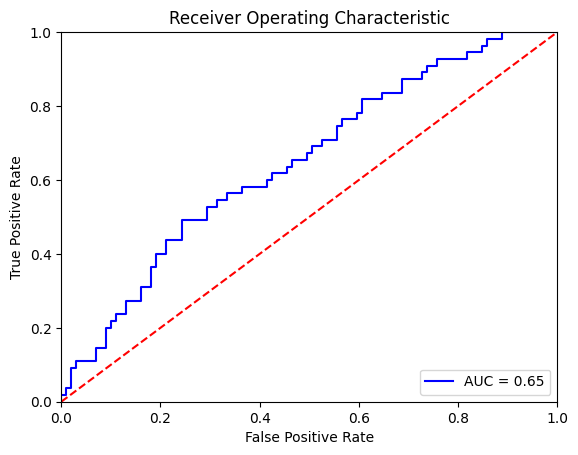

In [19]:
for param in model.bert.parameters():
    param.requires_grad = True

training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=20,
    per_device_train_batch_size=64,
    per_device_eval_batch_size=64,
    warmup_steps=500,
    learning_rate = 0.00001,
    weight_decay=0.001,
    logging_dir='./logs',
    logging_steps=10,
    eval_strategy="epoch",
    report_to='none'
)

# Evaluation metric
auc = evaluate.load("roc_auc")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = torch.softmax(torch.tensor(logits), dim=1).numpy()[:, 1]
    return auc.compute(prediction_scores=predictions, references=labels)

# Define the trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train_dataset,
    eval_dataset=tokenized_test_dataset,
    compute_metrics=compute_metrics,
    data_collator=data_collator
)

# Train the model
trainer.train()

results = trainer.evaluate()
print(results)

pred = trainer.predict(tokenized_test_dataset)
f1, thr = find_best_threshold(y_test, pred[0][:, 1])
print("test f1", f1)
print("test precision", precision_score(y_test, (pred[0][:, 1] >= thr).astype(int)))
print("test recall", recall_score(y_test, (pred[0][:, 1] >= thr).astype(int)))
print("test accuracy", accuracy_score(y_test, (pred[0][:, 1] >= thr).astype(int)))
fpr, tpr, threshold = roc_curve(y_test, pred[0][:, 1])
roc_auc = metrics.auc(fpr, tpr)
print("test roc_auc", roc_auc)
print("")

pred_train = trainer.predict(tokenized_train_dataset)
print("train f1", f1_score(y_train, np.argmax(pred_train[0], 1)))
print("train precision", precision_score(y_train, np.argmax(pred_train[0], 1)))
print("train recall", recall_score(y_train, np.argmax(pred_train[0], 1)))
print("train accuracy", accuracy_score(y_train, np.argmax(pred_train[0], 1)))

fpr_train, tpr_train, threshold_train = roc_curve(y_train, pred_train[0][:, 1])
roc_auc_train = metrics.auc(fpr_train, tpr_train)
print("train roc_auc", roc_auc_train)


plt.title('Receiver Operating Characteristic')
plt.plot(fpr, tpr, 'b', label = 'AUC = %0.2f' % roc_auc)
plt.legend(loc = 'lower right')
plt.plot([0, 1], [0, 1],'r--')
plt.xlim([0, 1])
plt.ylim([0, 1])
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.show()

In [20]:
scores = []
n_iter = 1000
multi = False
y_pred = (pred[0][:, 1] >= thr).astype(int)
for i in range(n_iter):
    y_true_boot, y_pred_boot, y_prob_boot = resample(y_test, y_pred, pred[0][:, 1], random_state=i+1)
    try:
        if multi:
            auc = roc_auc_score(y_true_boot, y_prob_boot, multi_class="ovr", average="macro")
            f1 = f1_score(y_true_boot, y_pred_boot, average="macro")
            pr = precision_score(y_true_boot, y_pred_boot, average="macro", zero_division=0)
            rc = recall_score (y_true_boot, y_pred_boot, average="macro", zero_division=0)
        else:
            auc = roc_auc_score(y_true_boot, y_prob_boot)
            f1  = f1_score(y_true_boot, y_pred_boot)
            pr  = precision_score(y_true_boot, y_pred_boot, zero_division=0)
            rc  = recall_score (y_true_boot, y_pred_boot, zero_division=0)
        scores.append((auc, f1, accuracy_score(y_true_boot, y_pred_boot), pr, rc))
    except ValueError:
        continue
scores = np.asarray(scores)
means, stds = scores.mean(0), scores.std(0, ddof=1)
names = ["ROC-AUC", "F1", "Accuracy", "Precision", "Recall"]
{n: f"{m:.4f}±{s:.4f}" for n, m, s in zip(names, means, stds)}

{'ROC-AUC': '0.6492±0.0452',
 'F1': '0.2297±0.0650',
 'Accuracy': '0.6508±0.0394',
 'Precision': '0.5418±0.1339',
 'Recall': '0.1478±0.0466'}

Map:   0%|          | 0/614 [00:00<?, ? examples/s]

Map:   0%|          | 0/154 [00:00<?, ? examples/s]

Map:   0%|          | 0/614 [00:00<?, ? examples/s]

Map:   0%|          | 0/154 [00:00<?, ? examples/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


...

test f1 0.0
test precision 0.0
test recall 0.0
test accuracy 0.6428571428571429
test roc_auc 0.5350780532598715



/Users/barebyxlol/Library/Python/3.9/lib/python/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/barebyxlol/Library/Python/3.9/lib/python/site-packages/torch/utils/data/dataloader.py:683: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)


  0%|          | 0/10 [00:00<?, ?it/s]

train f1 0.0
train precision 0.0
train recall 0.0
train accuracy 0.6530944625407166
train roc_auc 0.5332794773629308


/Users/barebyxlol/Library/Python/3.9/lib/python/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


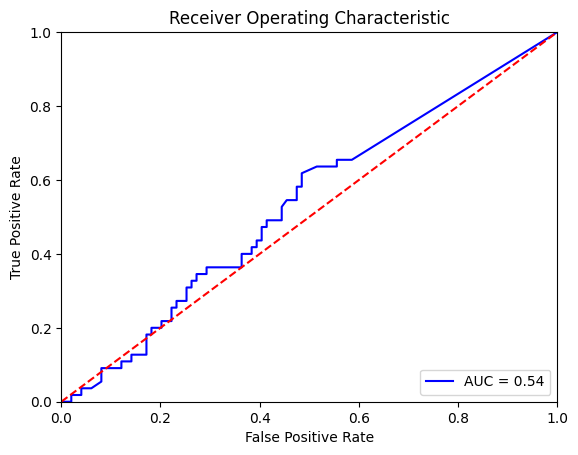

In [21]:
DROP_P = 0.9

X_train, X_test, y_train, y_test = train_test_split(df.drop('Outcome', axis =1),
                                                    df['Outcome'],
                                                    test_size=.2,
                                                    random_state = 42)
# y_train = y_train.replace({1:1, 2:0})
# y_test = y_test.replace({1:1, 2:0})

X_train['text'] = X_train.apply(lambda x: concatenate_text(x), axis=1)
X_test['text'] = X_test.apply(lambda x: concatenate_text(x), axis=1)

X_train['label'] = y_train
X_test['label'] = y_test

train_dataset = Dataset.from_pandas(X_train)
test_dataset = Dataset.from_pandas(X_test)

tokenized_train_dataset = train_dataset.map(tokenize_function, batched=True)
tokenized_test_dataset = test_dataset.map(tokenize_function, batched=True)

# Format the datasets correctly with labels
tokenized_train_dataset = tokenized_train_dataset.map(lambda x: {'labels': x['label']})
tokenized_test_dataset = tokenized_test_dataset.map(lambda x: {'labels': x['label']})

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

model = BertForSequenceClassification.from_pretrained('bert-base-uncased', num_labels=2).to('mps')

model.dropout.p = 0

for param in model.bert.parameters():
    param.requires_grad = False

training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=20,
    per_device_train_batch_size=64,
    per_device_eval_batch_size=64,
    warmup_steps=00,
    learning_rate = 0.1,
    weight_decay=0.001,
    logging_dir='./logs',
    logging_steps=10,
    eval_strategy="epoch",
    report_to='none'
)

# Evaluation metric
auc = evaluate.load("roc_auc")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = torch.softmax(torch.tensor(logits), dim=1).numpy()[:, 1]
    return auc.compute(prediction_scores=predictions, references=labels)

# Define the trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train_dataset,
    eval_dataset=tokenized_test_dataset,
    compute_metrics=compute_metrics,
    data_collator=data_collator
)

# Train the model
trainer.train()

results = trainer.evaluate()
print(results)

pred = trainer.predict(tokenized_test_dataset)
f1, thr = find_best_threshold(y_test, pred[0][:, 1])
print("test f1", f1)
print("test precision", precision_score(y_test, (pred[0][:, 1] >= thr).astype(int)))
print("test recall", recall_score(y_test, (pred[0][:, 1] >= thr).astype(int)))
print("test accuracy", accuracy_score(y_test, (pred[0][:, 1] >= thr).astype(int)))
fpr, tpr, threshold = roc_curve(y_test, pred[0][:, 1])
roc_auc = metrics.auc(fpr, tpr)
print("test roc_auc", roc_auc)
print("")

pred_train = trainer.predict(tokenized_train_dataset)
print("train f1", f1_score(y_train, np.argmax(pred_train[0], 1)))
print("train precision", precision_score(y_train, np.argmax(pred_train[0], 1)))
print("train recall", recall_score(y_train, np.argmax(pred_train[0], 1)))
print("train accuracy", accuracy_score(y_train, np.argmax(pred_train[0], 1)))

fpr_train, tpr_train, threshold_train = roc_curve(y_train, pred_train[0][:, 1])
roc_auc_train = metrics.auc(fpr_train, tpr_train)
print("train roc_auc", roc_auc_train)


plt.title('Receiver Operating Characteristic')
plt.plot(fpr, tpr, 'b', label = 'AUC = %0.2f' % roc_auc)
plt.legend(loc = 'lower right')
plt.plot([0, 1], [0, 1],'r--')
plt.xlim([0, 1])
plt.ylim([0, 1])
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.show()

  0%|          | 0/200 [00:00<?, ?it/s]

/Users/barebyxlol/Library/Python/3.9/lib/python/site-packages/torch/utils/data/dataloader.py:683: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)


{'loss': 0.6398, 'grad_norm': 9.992539405822754, 'learning_rate': 2.0000000000000002e-07, 'epoch': 1.0}


  0%|          | 0/3 [00:00<?, ?it/s]

{'eval_loss': 0.6852680444717407, 'eval_roc_auc': 0.5310376492194674, 'eval_runtime': 2.4683, 'eval_samples_per_second': 62.391, 'eval_steps_per_second': 1.215, 'epoch': 1.0}


...

test f1 0.0
test precision 0.0
test recall 0.0
test accuracy 0.6428571428571429
test roc_auc 0.5672176308539945



/Users/barebyxlol/Library/Python/3.9/lib/python/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/barebyxlol/Library/Python/3.9/lib/python/site-packages/torch/utils/data/dataloader.py:683: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)


  0%|          | 0/10 [00:00<?, ?it/s]

train f1 0.0
train precision 0.0
train recall 0.0
train accuracy 0.6530944625407166
train roc_auc 0.551848079332186


/Users/barebyxlol/Library/Python/3.9/lib/python/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


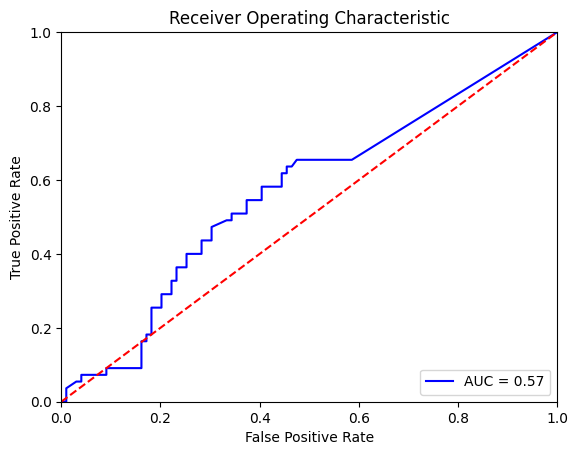

In [22]:
for param in model.bert.parameters():
    param.requires_grad = True

training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=20,
    per_device_train_batch_size=64,
    per_device_eval_batch_size=64,
    warmup_steps=500,
    learning_rate = 0.00001,
    weight_decay=0.001,
    logging_dir='./logs',
    logging_steps=10,
    eval_strategy="epoch",
    report_to='none'
)

# Evaluation metric
auc = evaluate.load("roc_auc")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = torch.softmax(torch.tensor(logits), dim=1).numpy()[:, 1]
    return auc.compute(prediction_scores=predictions, references=labels)

# Define the trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train_dataset,
    eval_dataset=tokenized_test_dataset,
    compute_metrics=compute_metrics,
    data_collator=data_collator
)

# Train the model
trainer.train()

results = trainer.evaluate()
print(results)

pred = trainer.predict(tokenized_test_dataset)
f1, thr = find_best_threshold(y_test, pred[0][:, 1])
print("test f1", f1)
print("test precision", precision_score(y_test, (pred[0][:, 1] >= thr).astype(int)))
print("test recall", recall_score(y_test, (pred[0][:, 1] >= thr).astype(int)))
print("test accuracy", accuracy_score(y_test, (pred[0][:, 1] >= thr).astype(int)))
fpr, tpr, threshold = roc_curve(y_test, pred[0][:, 1])
roc_auc = metrics.auc(fpr, tpr)
print("test roc_auc", roc_auc)
print("")

pred_train = trainer.predict(tokenized_train_dataset)
print("train f1", f1_score(y_train, np.argmax(pred_train[0], 1)))
print("train precision", precision_score(y_train, np.argmax(pred_train[0], 1)))
print("train recall", recall_score(y_train, np.argmax(pred_train[0], 1)))
print("train accuracy", accuracy_score(y_train, np.argmax(pred_train[0], 1)))

fpr_train, tpr_train, threshold_train = roc_curve(y_train, pred_train[0][:, 1])
roc_auc_train = metrics.auc(fpr_train, tpr_train)
print("train roc_auc", roc_auc_train)


plt.title('Receiver Operating Characteristic')
plt.plot(fpr, tpr, 'b', label = 'AUC = %0.2f' % roc_auc)
plt.legend(loc = 'lower right')
plt.plot([0, 1], [0, 1],'r--')
plt.xlim([0, 1])
plt.ylim([0, 1])
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.show()

In [23]:
scores = []
n_iter = 1000
multi = False
y_pred = (pred[0][:, 1] >= thr).astype(int)
for i in range(n_iter):
    y_true_boot, y_pred_boot, y_prob_boot = resample(y_test, y_pred, pred[0][:, 1], random_state=i+1)
    try:
        if multi:
            auc = roc_auc_score(y_true_boot, y_prob_boot, multi_class="ovr", average="macro")
            f1 = f1_score(y_true_boot, y_pred_boot, average="macro")
            pr = precision_score(y_true_boot, y_pred_boot, average="macro", zero_division=0)
            rc = recall_score (y_true_boot, y_pred_boot, average="macro", zero_division=0)
        else:
            auc = roc_auc_score(y_true_boot, y_prob_boot)
            f1  = f1_score(y_true_boot, y_pred_boot)
            pr  = precision_score(y_true_boot, y_pred_boot, zero_division=0)
            rc  = recall_score (y_true_boot, y_pred_boot, zero_division=0)
        scores.append((auc, f1, accuracy_score(y_true_boot, y_pred_boot), pr, rc))
    except ValueError:
        continue
scores = np.asarray(scores)
means, stds = scores.mean(0), scores.std(0, ddof=1)
names = ["ROC-AUC", "F1", "Accuracy", "Precision", "Recall"]
{n: f"{m:.4f}±{s:.4f}" for n, m, s in zip(names, means, stds)}

{'ROC-AUC': '0.5681±0.0470',
 'F1': '0.0000±0.0000',
 'Accuracy': '0.6429±0.0403',
 'Precision': '0.0000±0.0000',
 'Recall': '0.0000±0.0000'}

Map:   0%|          | 0/614 [00:00<?, ? examples/s]

Map:   0%|          | 0/154 [00:00<?, ? examples/s]

Map:   0%|          | 0/614 [00:00<?, ? examples/s]

Map:   0%|          | 0/154 [00:00<?, ? examples/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


...

test f1 0.0
test precision 0.0
test recall 0.0
test accuracy 0.6428571428571429
test roc_auc 0.5854912764003672



/Users/barebyxlol/Library/Python/3.9/lib/python/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/barebyxlol/Library/Python/3.9/lib/python/site-packages/torch/utils/data/dataloader.py:683: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)


  0%|          | 0/10 [00:00<?, ?it/s]

train f1 0.0
train precision 0.0
train recall 0.0
train accuracy 0.6530944625407166
train roc_auc 0.6695936215798532


/Users/barebyxlol/Library/Python/3.9/lib/python/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


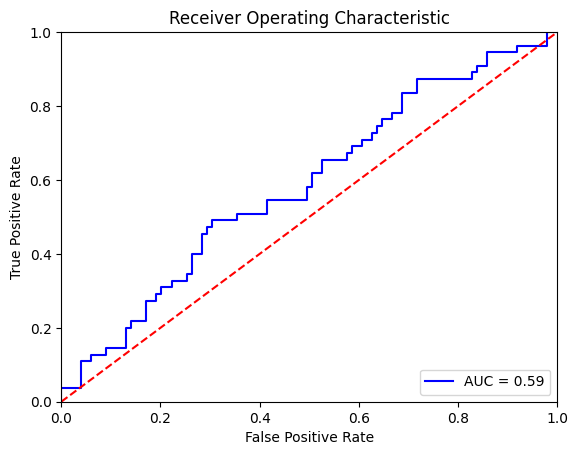

In [24]:
DROP_P = 0

X_train, X_test, y_train, y_test = train_test_split(df.drop('Outcome', axis =1),
                                                    df['Outcome'],
                                                    test_size=.2,
                                                    random_state = 42)
# y_train = y_train.replace({1:1, 2:0})
# y_test = y_test.replace({1:1, 2:0})

X_train['text'] = X_train.apply(lambda x: concatenate_text(x), axis=1)
X_test['text'] = X_test.apply(lambda x: concatenate_text(x), axis=1)

X_train['label'] = y_train
X_test['label'] = y_test

train_dataset = Dataset.from_pandas(X_train)
test_dataset = Dataset.from_pandas(X_test)

tokenized_train_dataset = train_dataset.map(tokenize_function, batched=True)
tokenized_test_dataset = test_dataset.map(tokenize_function, batched=True)

# Format the datasets correctly with labels
tokenized_train_dataset = tokenized_train_dataset.map(lambda x: {'labels': x['label']})
tokenized_test_dataset = tokenized_test_dataset.map(lambda x: {'labels': x['label']})

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

model = BertForSequenceClassification.from_pretrained('bert-base-uncased', num_labels=2).to('mps')

model.dropout.p = 0

for param in model.bert.parameters():
    param.requires_grad = False

training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=20,
    per_device_train_batch_size=64,
    per_device_eval_batch_size=64,
    warmup_steps=00,
    learning_rate = 0.1,
    weight_decay=0.001,
    logging_dir='./logs',
    logging_steps=10,
    eval_strategy="epoch",
    report_to='none'
)

# Evaluation metric
auc = evaluate.load("roc_auc")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = torch.softmax(torch.tensor(logits), dim=1).numpy()[:, 1]
    return auc.compute(prediction_scores=predictions, references=labels)

# Define the trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train_dataset,
    eval_dataset=tokenized_test_dataset,
    compute_metrics=compute_metrics,
    data_collator=data_collator
)

# Train the model
trainer.train()

results = trainer.evaluate()
print(results)

pred = trainer.predict(tokenized_test_dataset)
f1, thr = find_best_threshold(y_test, pred[0][:, 1])
print("test f1", f1)
print("test precision", precision_score(y_test, (pred[0][:, 1] >= thr).astype(int)))
print("test recall", recall_score(y_test, (pred[0][:, 1] >= thr).astype(int)))
print("test accuracy", accuracy_score(y_test, (pred[0][:, 1] >= thr).astype(int)))
fpr, tpr, threshold = roc_curve(y_test, pred[0][:, 1])
roc_auc = metrics.auc(fpr, tpr)
print("test roc_auc", roc_auc)
print("")

pred_train = trainer.predict(tokenized_train_dataset)
print("train f1", f1_score(y_train, np.argmax(pred_train[0], 1)))
print("train precision", precision_score(y_train, np.argmax(pred_train[0], 1)))
print("train recall", recall_score(y_train, np.argmax(pred_train[0], 1)))
print("train accuracy", accuracy_score(y_train, np.argmax(pred_train[0], 1)))

fpr_train, tpr_train, threshold_train = roc_curve(y_train, pred_train[0][:, 1])
roc_auc_train = metrics.auc(fpr_train, tpr_train)
print("train roc_auc", roc_auc_train)


plt.title('Receiver Operating Characteristic')
plt.plot(fpr, tpr, 'b', label = 'AUC = %0.2f' % roc_auc)
plt.legend(loc = 'lower right')
plt.plot([0, 1], [0, 1],'r--')
plt.xlim([0, 1])
plt.ylim([0, 1])
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.show()

  0%|          | 0/200 [00:00<?, ?it/s]

/Users/barebyxlol/Library/Python/3.9/lib/python/site-packages/torch/utils/data/dataloader.py:683: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)


{'loss': 0.6623, 'grad_norm': 11.05417537689209, 'learning_rate': 2.0000000000000002e-07, 'epoch': 1.0}


  0%|          | 0/3 [00:00<?, ?it/s]

{'eval_loss': 0.6776049733161926, 'eval_roc_auc': 0.5849403122130394, 'eval_runtime': 2.5673, 'eval_samples_per_second': 59.984, 'eval_steps_per_second': 1.169, 'epoch': 1.0}


...

  0%|          | 0/3 [00:00<?, ?it/s]

test f1 0.546875
test precision 0.4794520547945205
test recall 0.6363636363636364
test accuracy 0.6233766233766234
test roc_auc 0.6852157943067034



/Users/barebyxlol/Library/Python/3.9/lib/python/site-packages/torch/utils/data/dataloader.py:683: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)


  0%|          | 0/10 [00:00<?, ?it/s]

train f1 0.5800865800865801
train precision 0.5381526104417671
train recall 0.6291079812206573
train accuracy 0.6840390879478827
train roc_auc 0.7685715289241685


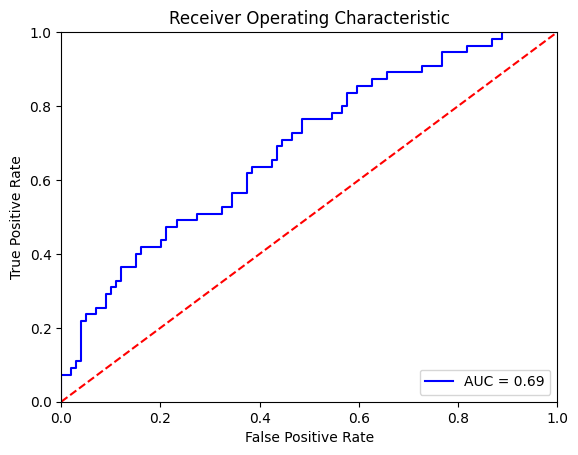

In [25]:
for param in model.bert.parameters():
    param.requires_grad = True

training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=20,
    per_device_train_batch_size=64,
    per_device_eval_batch_size=64,
    warmup_steps=500,
    learning_rate = 0.00001,
    weight_decay=0.001,
    logging_dir='./logs',
    logging_steps=10,
    eval_strategy="epoch",
    report_to='none'
)

# Evaluation metric
auc = evaluate.load("roc_auc")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = torch.softmax(torch.tensor(logits), dim=1).numpy()[:, 1]
    return auc.compute(prediction_scores=predictions, references=labels)

# Define the trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train_dataset,
    eval_dataset=tokenized_test_dataset,
    compute_metrics=compute_metrics,
    data_collator=data_collator
)

# Train the model
trainer.train()

results = trainer.evaluate()
print(results)

pred = trainer.predict(tokenized_test_dataset)
f1, thr = find_best_threshold(y_test, pred[0][:, 1])
print("test f1", f1)
print("test precision", precision_score(y_test, (pred[0][:, 1] >= thr).astype(int)))
print("test recall", recall_score(y_test, (pred[0][:, 1] >= thr).astype(int)))
print("test accuracy", accuracy_score(y_test, (pred[0][:, 1] >= thr).astype(int)))
fpr, tpr, threshold = roc_curve(y_test, pred[0][:, 1])
roc_auc = metrics.auc(fpr, tpr)
print("test roc_auc", roc_auc)
print("")

pred_train = trainer.predict(tokenized_train_dataset)
print("train f1", f1_score(y_train, np.argmax(pred_train[0], 1)))
print("train precision", precision_score(y_train, np.argmax(pred_train[0], 1)))
print("train recall", recall_score(y_train, np.argmax(pred_train[0], 1)))
print("train accuracy", accuracy_score(y_train, np.argmax(pred_train[0], 1)))

fpr_train, tpr_train, threshold_train = roc_curve(y_train, pred_train[0][:, 1])
roc_auc_train = metrics.auc(fpr_train, tpr_train)
print("train roc_auc", roc_auc_train)


plt.title('Receiver Operating Characteristic')
plt.plot(fpr, tpr, 'b', label = 'AUC = %0.2f' % roc_auc)
plt.legend(loc = 'lower right')
plt.plot([0, 1], [0, 1],'r--')
plt.xlim([0, 1])
plt.ylim([0, 1])
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.show()

In [26]:
scores = []
n_iter = 1000
multi = False
y_pred = (pred[0][:, 1] >= thr).astype(int)
for i in range(n_iter):
    y_true_boot, y_pred_boot, y_prob_boot = resample(y_test, y_pred, pred[0][:, 1], random_state=i+1)
    try:
        if multi:
            auc = roc_auc_score(y_true_boot, y_prob_boot, multi_class="ovr", average="macro")
            f1 = f1_score(y_true_boot, y_pred_boot, average="macro")
            pr = precision_score(y_true_boot, y_pred_boot, average="macro", zero_division=0)
            rc = recall_score (y_true_boot, y_pred_boot, average="macro", zero_division=0)
        else:
            auc = roc_auc_score(y_true_boot, y_prob_boot)
            f1  = f1_score(y_true_boot, y_pred_boot)
            pr  = precision_score(y_true_boot, y_pred_boot, zero_division=0)
            rc  = recall_score (y_true_boot, y_pred_boot, zero_division=0)
        scores.append((auc, f1, accuracy_score(y_true_boot, y_pred_boot), pr, rc))
    except ValueError:
        continue
scores = np.asarray(scores)
means, stds = scores.mean(0), scores.std(0, ddof=1)
names = ["ROC-AUC", "F1", "Accuracy", "Precision", "Recall"]
{n: f"{m:.4f}±{s:.4f}" for n, m, s in zip(names, means, stds)}

{'ROC-AUC': '0.6865±0.0440',
 'F1': '0.5458±0.0520',
 'Accuracy': '0.6244±0.0390',
 'Precision': '0.4803±0.0577',
 'Recall': '0.6371±0.0640'}